In [154]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [155]:
df = pd.read_csv("insurance.csv")

In [156]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


# EDA - Exploratory Data Analysis 

In [157]:
df.shape

(1338, 7)

In [158]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [159]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [160]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [161]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [162]:
numeric_columns=['age','bmi','children','charges']
df[numeric_columns].head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


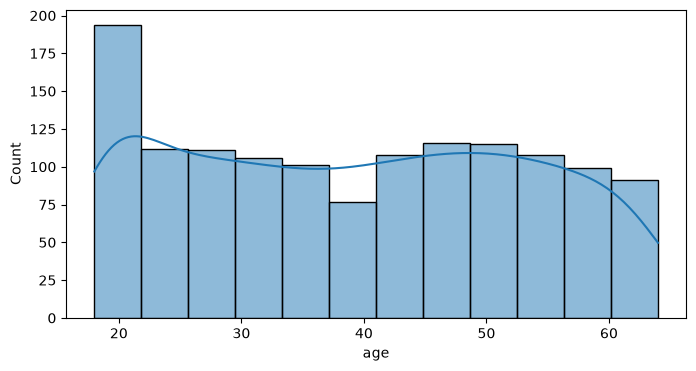

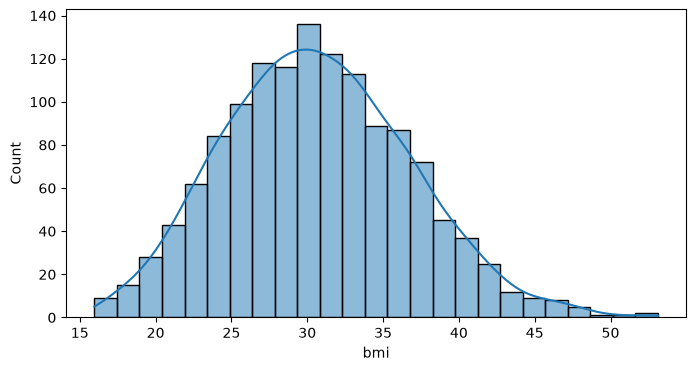

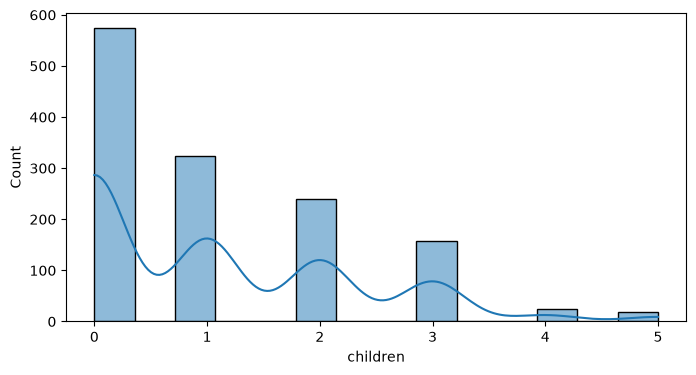

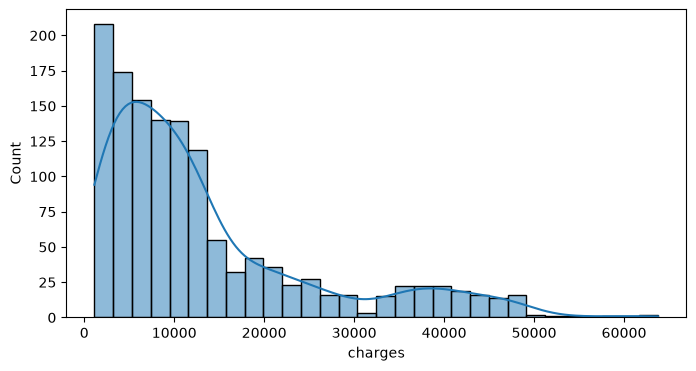

In [163]:

for i in numeric_columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[i],kde=True,palette="magma")

<Axes: xlabel='children', ylabel='count'>

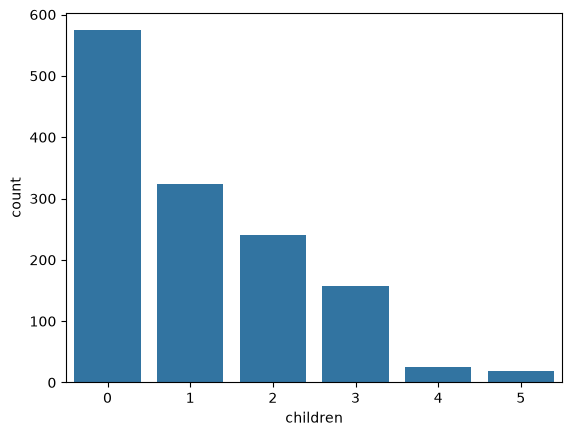

In [164]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

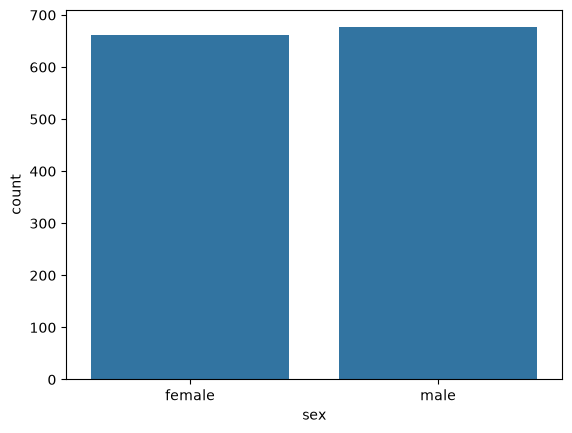

In [165]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

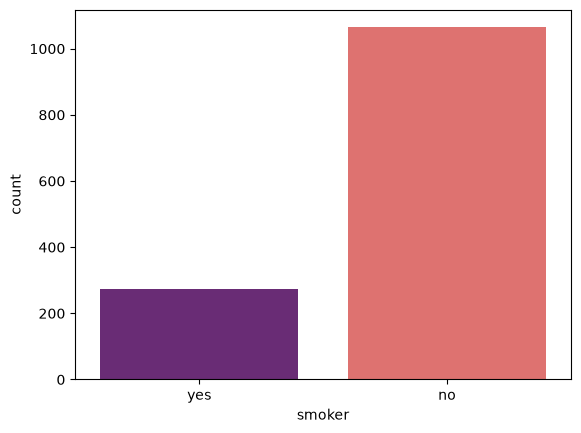

In [166]:
sns.countplot(x=df['smoker'],palette="magma")

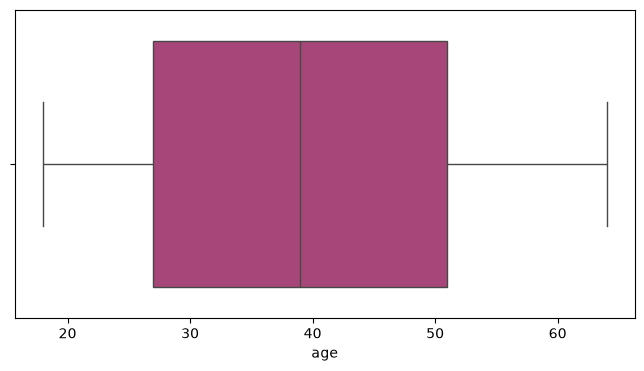

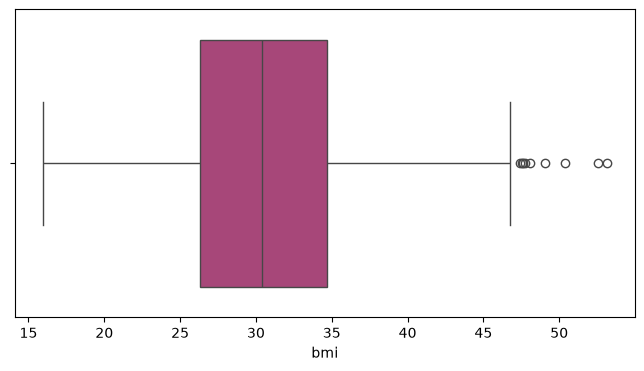

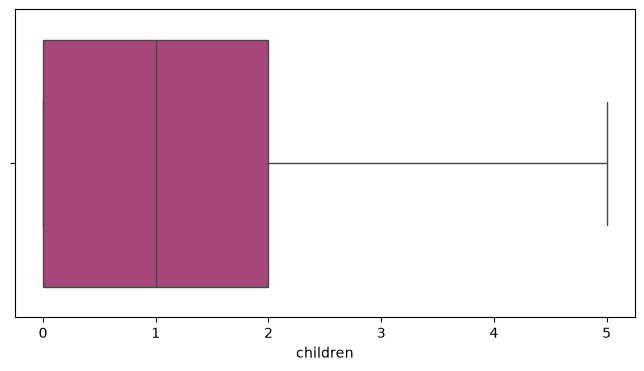

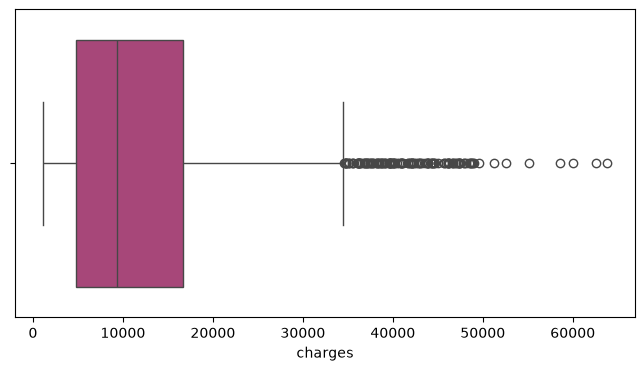

In [167]:
for i in numeric_columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[i],palette="magma")

<Axes: >

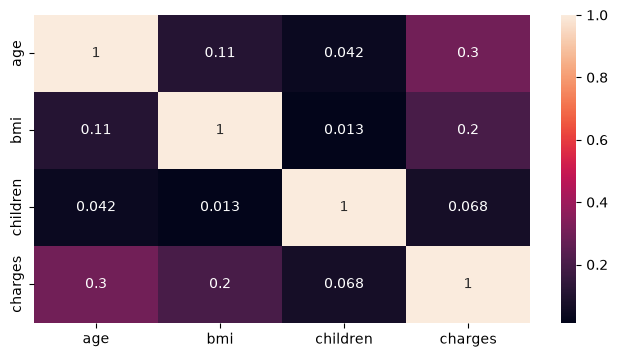

In [168]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning and PreProcessing 

In [169]:
clean_df=df.copy()
clean_df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [170]:
clean_df.shape

(1338, 7)

In [171]:
clean_df.drop_duplicates(inplace=True)

In [172]:
clean_df.shape

(1337, 7)

In [173]:
clean_df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [174]:
clean_df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [175]:
clean_df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [176]:
# label encoding
clean_df['sex'] = clean_df['sex'].map({'male':0,'female':1})
clean_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [177]:
clean_df['smoker'] = clean_df['smoker'].map({'yes':1,"no":0})
clean_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [178]:
clean_df.rename(columns={
    'sex':"is_female",
    'smoker':"is_smoker"
},inplace=True)
clean_df.head(1)

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.9,0,1,southwest,16884.924


In [179]:
clean_df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [180]:
# Hot Encodding
clean_df = pd.get_dummies(clean_df,columns=["region"],drop_first=True)
clean_df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [181]:
clean_df=clean_df.replace({True:1,False:0})
# clean_df=clean_df.astype(int)

In [182]:
clean_df.head(2)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.90,0,1,16884.9240,0,0,1
1,18,0,33.77,1,0,1725.5523,0,1,0


### Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

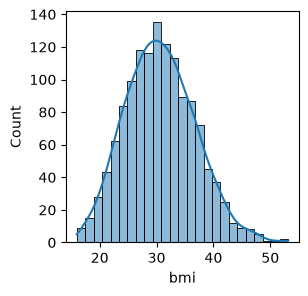

In [183]:
plt.figure(figsize=(3,3))
sns.histplot(clean_df['bmi'],kde=True)

In [184]:
clean_df["bmi_category"] = pd.cut(
    clean_df['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=["Underweight","Normal","Overweight","Obese"]
)

In [185]:
clean_df.head(2)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.90,0,1,16884.9240,0,0,1,Overweight
1,18,0,33.77,1,0,1725.5523,0,1,0,Obese


In [186]:
clean_df=pd.get_dummies(clean_df ,columns=['bmi_category'],drop_first=True)

In [187]:
clean_df = clean_df.astype(int)
clean_df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


### Data Scaling

In [193]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
cols = ['age',"bmi","children"]
clean_df[cols] = scalar.fit_transform(clean_df[cols])

In [194]:
clean_df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
